In [18]:
import os
import zipfile
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.models import load_model

# --- 1. SETUP ENVIRONMENT ---
print("--- 1. Setting up Environment ---")

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✅ Google Drive mounted.")
else:
    print("✅ Google Drive already mounted.")

# Verify GPU
gpu_count = len(tf.config.list_physical_devices('GPU'))
if gpu_count > 0:
    print(f"✅ GPU Active: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print("⚠️ WARNING: No GPU detected. Processing video will be slow.")


# --- 2. EXTRACT DATA (RAVDESS) ---
print("\n--- 2. Extracting RAVDESS Dataset ---")

zip_path = '/content/drive/MyDrive/RAVDESS_Video_Speech.zip'
extract_path = '/content/ravdess_data'

if not os.path.exists(extract_path):
    if os.path.exists(zip_path):
        print(f"⏳ Extracting {zip_path}... this may take a moment.")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Extraction complete!")
    else:
        print(f"❌ Error: Zip file not found at {zip_path}")
else:
    print("✅ Data already extracted.")


# --- 3. LOAD TRAINED CNN MODEL ---
print("\n--- 3. Loading Feature Extractor (CNN) ---")

model_path = '/content/drive/MyDrive/final_fer_mini_xception.keras'

if os.path.exists(model_path):
    cnn_model = load_model(model_path)
    print(f"✅ CNN Model successfully loaded from: {model_path}")
    # Optional: Print input shape to verify
    print(f"   Model expects input shape: {cnn_model.input_shape}")
else:
    print(f"❌ Error: Model not found at {model_path}")
    print("   Please check the filename in your Google Drive.")

print("\n🚀 READY FOR VIDEO PROCESSING")

--- 1. Setting up Environment ---
✅ Google Drive already mounted.
⚠️ WARNING: No GPU detected. Processing video will be slow.

--- 2. Extracting RAVDESS Dataset ---
✅ Data already extracted.

--- 3. Loading Feature Extractor (CNN) ---
✅ CNN Model successfully loaded from: /content/drive/MyDrive/final_fer_mini_xception.keras
   Model expects input shape: (None, 48, 48, 1)

🚀 READY FOR VIDEO PROCESSING


In [19]:
import cv2          # OpenCV for image processing
import numpy as np  # Arrays and math
import os           # File system navigation
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# --- CONFIGURATION ---
SEQUENCE_LENGTH = 20   # TARGET: We want exactly 20 frames per video
IMG_SIZE = 48          # TARGET: Your Mini-Xception expects 48x48 pixels
ACTOR_FOLDER = "Actor_01" # We focus on Actor 01
BASE_PATH = "/content/ravdess_data" # Path to unzipped data

# --- LOAD FACE DETECTOR ---
# We download the official OpenCV Haar Cascade XML
haar_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
haar_path = tf.keras.utils.get_file("haarcascade_frontalface_default.xml", haar_url)
face_cascade = cv2.CascadeClassifier(haar_path)

print("✅ Configuration loaded. Face detector ready.")

✅ Configuration loaded. Face detector ready.


In [20]:
# --- The "Frame Extractor" Function -----
def extract_features_from_video(video_path):
    """
    1. Opens video.
    2. Selects exactly 20 frames (evenly spaced).
    3. Detects face, crops, and resizes to 48x48.
    4. Feeds to CNN to get emotion probabilities.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # MATH: Calculate the "Step" to get exactly 20 frames.
    # Example: 100 frames / 20 = Step 5 (Take frame 0, 5, 10, 15...)
    skip_frames_window = max(int(total_frames / SEQUENCE_LENGTH), 1)

    frames_features = []

    for i in range(SEQUENCE_LENGTH):
        # 1. Calculate which frame index to grab
        frame_id = i * skip_frames_window
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

        # 2. Read the frame
        success, frame = cap.read()
        if not success:
            break

        # 3. Pre-processing (Gray + Face Detection)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Converts the colorful frame to Grayscale.
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)  # Returns: A list of coordinates [x, y, w, h] for every face found.

        # 4. Crop Face (or use full frame if detection fails)
        if len(faces) > 0:
            x, y, w, h = faces[0]
            face_img = gray[y:y+h, x:x+w]
        else:
            face_img = gray

        # 5. Resize to 48x48 (Model Input Size)
        resized = cv2.resize(face_img, (IMG_SIZE, IMG_SIZE))

        # 6. Normalize (0 to 1)
        normalized = resized.astype('float32') / 255.0

        # # 7. Reshape for CNN (1, 48, 48, 1)
        # cnn_input = np.expand_dims(normalized, axis=0)
        # cnn_input = np.expand_dims(cnn_input, axis=-1)

        # # 8. Extract Features (Get the 7 probabilities)
        # features = cnn_model.predict(cnn_input, verbose=0)
        frames_features.append(normalized)

    cap.release()

    # SAFETY: If video was too short, pad with zeros to match length 20
    while len(frames_features) < SEQUENCE_LENGTH:
        # frames_features.append(np.zeros(7))
        frames_features.append(np.zeros((IMG_SIZE, IMG_SIZE), dtype='float32'))

    # --- THE OPTIMIZATION IS HERE ---
    # 1. Convert list to a single big Numpy block: Shape (20, 48, 48)
    batch_numpy = np.array(frames_features)

    # 2. Add the Channel dimension: Shape (20, 48, 48, 1)
    batch_numpy = np.expand_dims(batch_numpy, axis=-1)

    # 3. Predict ALL 20 frames at once
    # This runs 1 time instead of 20 times.
    features = cnn_model.predict(batch_numpy, verbose=0)

    # return np.array(frames_features)
    return features

print("✅ Helper function defined.")


✅ Helper function defined.


In [21]:
# ----- The Main Processing Loop -----
X_lstm = [] # Inputs: (Videos, 20, 7)
y_lstm = [] # Labels: (Videos, 1)

# --- MAP RAVDESS TO FER-2013 ---
# RAVDESS Codes: 01=Neutral, 02=Calm, 03=Happy, 04=Sad, 05=Angry, 06=Fear, 07=Disgust, 08=Surprise
# FER-2013 Indices: 0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Neutral, 5=Sad, 6=Surprise
ravdess_to_fer_map = {
    '01': 4, # Neutral -> Neutral
    '02': 4, # Calm -> Neutral
    '03': 3, # Happy -> Happy
    '04': 5, # Sad -> Sad
    '05': 0, # Angry -> Angry
    '06': 2, # Fear -> Fear
    '07': 1, # Disgust -> Disgust
    '08': 6  # Surprise -> Surprise
}

# --- FIND ACTOR FOLDER ---
# Search logic to handle different zip structures (search till it finds "Actor-01" folder)
search_path = os.path.join(BASE_PATH, ACTOR_FOLDER)
if not os.path.exists(search_path):
    for root, dirs, files in os.walk(BASE_PATH):
        if ACTOR_FOLDER in dirs:
            search_path = os.path.join(root, ACTOR_FOLDER)
            break

print(f"📂 Processing videos in: {search_path}")

# --- PROCESS VIDEOS ---
file_count = 0
for filename in os.listdir(search_path):
    if filename.endswith(".mp4"):
        # Parse Emotion Code (3rd part of filename: "01-01-01-01-01-01-01.mp4")
        parts = filename.split('-')

        # The RAVDESS dataset follows a strict international standard and we're only interested in emotions which is indexed at 2
        # The structure is: Modality - Channel - Emotion - Intensity - Statement - Repetition - Actor
        emotion_code = parts[2]

        if emotion_code in ravdess_to_fer_map:
            video_path = os.path.join(search_path, filename)

            # CALL FUNCTION
            features = extract_features_from_video(video_path)

            # STORE DATA
            X_lstm.append(features)
            y_lstm.append(ravdess_to_fer_map[emotion_code])

            file_count += 1
            if file_count % 10 == 0: print(f"   Processed {file_count} videos...")

# --- FINALIZE DATA ---
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
y_lstm_onehot = to_categorical(y_lstm, num_classes=7)

print("\n🎉 DONE! Data Ready for LSTM.")
print(f"X Shape: {X_lstm.shape}")
print(f"y Shape: {y_lstm_onehot.shape}")

📂 Processing videos in: /content/ravdess_data/RAVDESS_Video_Speech/Video_Speech_Actor_01/Actor_01


   Processed 10 videos...
   Processed 20 videos...
   Processed 30 videos...
   Processed 40 videos...
   Processed 50 videos...
   Processed 60 videos...
   Processed 70 videos...
   Processed 80 videos...
   Processed 90 videos...
   Processed 100 videos...
   Processed 110 videos...
   Processed 120 videos...

🎉 DONE! Data Ready for LSTM.
X Shape: (120, 20, 7) (Should be: Num_Videos, 20, 7)
y Shape: (120, 7) (Should be: Num_Videos, 7)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

lstm_model = Sequential()

# Input Shape: (20 time steps, 7 features per step)
lstm_model.add(Input(shape=(SEQUENCE_LENGTH, 7)))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(7, activation='softmax')) # Final prediction for the video

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# --- CORRECTION IS HERE ---
history = lstm_model.fit(X_lstm, y_lstm_onehot, epochs=50, batch_size=8, validation_split=0.2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,743 (81.03 KB)

 Trainable params: 20,743 (81.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1669 - loss: 1.9291 - val_accuracy: 0.3333 - val_loss: 1.8882
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3167 - loss: 1.8550 - val_accuracy: 0.4167 - val_loss: 1.7937
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4378 - loss: 1.7659 - val_accuracy: 0.4167 - val_loss: 1.6550
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5141 - loss: 1.4790 - val_accuracy: 0.4583 - val_loss: 1.3838
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5834 - loss: 1.3104 - val_accuracy: 0.4583 - val_loss: 1.2730
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4041 - loss: 1.3433 - val_accuracy: 0.4583 - val_loss: 1.2451
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6014 - loss: 0.9640 - val_accuracy: 0.5833 - val_loss: 1.1061
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5847 - loss: 0.9177 - val_accuracy: 0.5000 - v

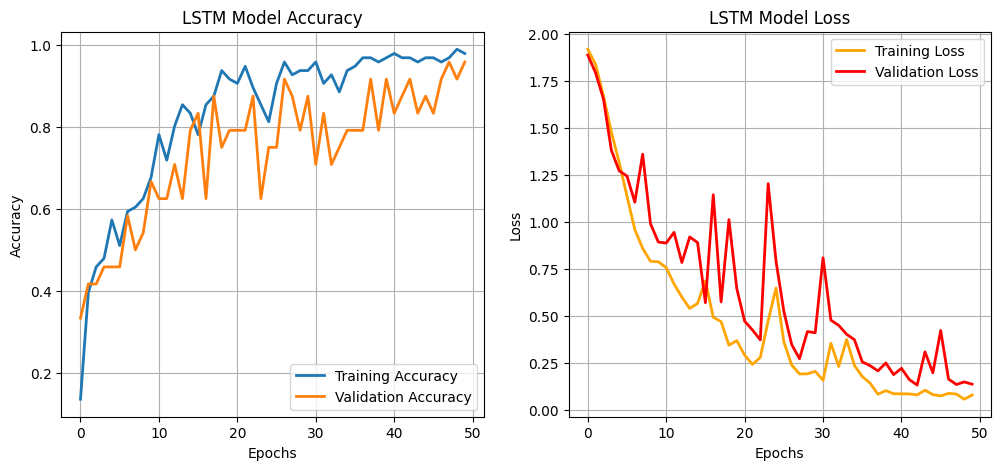


--- Generating Confusion Matrix ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


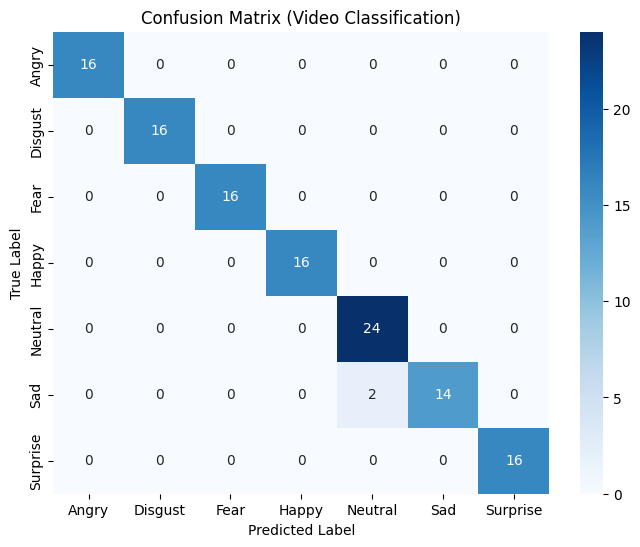


--- Classification Report ---
              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00        16
     Disgust       1.00      1.00      1.00        16
        Fear       1.00      1.00      1.00        16
       Happy       1.00      1.00      1.00        16
     Neutral       0.92      1.00      0.96        24
         Sad       1.00      0.88      0.93        16
    Surprise       1.00      1.00      1.00        16

    accuracy                           0.98       120
   macro avg       0.99      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --- PART 1: PLOT TRAINING CURVES ---
try:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)
    plt.title('LSTM Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='orange', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='red', linewidth=2)
    plt.title('LSTM Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()
except NameError:
    print("⚠️ Could not plot training curves. The variable 'history' was not found.")
    print("   (Did you run 'history = lstm_model.fit(...)'? If not, only the matrix below will work.)")


# --- PART 2: EVALUATE & CONFUSION MATRIX ---
# This part works even if you lost the history variable, as long as 'lstm_model' exists.
print("\n--- Generating Confusion Matrix ---")

# 1. Get Predictions from the LSTM Model
y_pred_probs = lstm_model.predict(X_lstm)
y_pred = np.argmax(y_pred_probs, axis=1) # Pick the highest probability class
y_true = np.argmax(y_lstm_onehot, axis=1) # Pick the true class

# 2. Define Labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# 3. Create & Plot Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Video Classification)')
plt.show()

# 4. Print Detailed Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=emotion_labels, zero_division=0))